In [37]:
!pip3 install -q imbalanced-learn

In [52]:
import pandas as pd
from IPython import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,roc_curve,
mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib
print("All modules imported!!")

All modules imported!!


In [28]:
df = pd.read_csv("titanic.csv")
scaler = StandardScaler()
print(f"Columns before dropping: \n {df.columns}")
#Columns: who, alive,alone,adultmale,class - these are redundant columns since data to these columns is derived from sex, survived, parch, age and sex, pclass, hence dropping these columns as well.
df = df.drop(columns=['who','class','adult_male','alive','alone','embark_town'])
print(f"Columns after dropping irrelevant columns: {df.columns}")

Columns before dropping: 
 Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
Columns after dropping irrelevant columns: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='str')


In [29]:
#Dropping columns whose missing count is greater than 30 percent
missing_count = df.isnull().sum()
cols = df.columns
missing_percent = ((missing_count / len(X_train)) * 100).round(2)
drop_cols = missing_percent[missing_percent > 30].index.tolist()
#Dropping columns whose missing values are greater than 50 percent. 
if drop_cols:
    print(f"Dropping column whose missing values are more than 30 percent: {drop_cols}")
    df = df.drop(columns = drop_cols)
#Splitting the dataset into X and y using train_test_split and stratify as option, we are using stratify because the dataset is unbalanced
#Target variable is imbalanced, non survivors are approximately 61.6% where as survivors contribute only 38.4% hence stratify is required for this splitting
X = df.drop(columns = ['survived'])
y = df['survived']
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
#Numerical pipeline: Handling missing values --> Impute age (mean) + Scale age and Fare
num_features = ['age','fare']
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
#Categorical Pipeline: Impute missing with mode + one hot encode sex and embarked, I am using one hot encode for both sex and embarked.
#If I use label encoding for embarked, it might introduce unwanted ordering, hence I am using one hot encode.
cat_features = ['sex','embarked']
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(drop='first', sparse_output=False,
    handle_unknown = 'ignore'))
])
#Column Transformer
preprocessor = ColumnTransformer(
    transformers = [
        ('num',num_pipeline, num_features),
        ('cat',cat_pipeline, cat_features)
    ],
    remainder = 'passthrough'
)
preprocessor.set_output(transform = 'pandas') # Configure output to return a pandas Dataframe
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"X_train shape: {X_train_processed.shape}")
print(f"X_test shape:  {X_test_processed.shape}\n")
print("Transformed Feature Columns:")
print(X_train_processed.columns.tolist())
X_train_processed.head()

Dropping column whose missing values are more than 30 percent: ['deck']
X_train shape: (712, 8)
X_test shape:  (179, 8)

Transformed Feature Columns:
['num__age', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'remainder__pclass', 'remainder__sibsp', 'remainder__parch']


,num__age,num__fare,cat__sex_male,cat__embarked_Q,cat__embarked_S,remainder__pclass,remainder__sibsp,remainder__parch
692,-5.463229e-16,0.513812,1.0,0.0,1.0,3,0,0
481,-5.463229e-16,-0.662563,1.0,0.0,1.0,2,0,0
527,-5.463229e-16,3.955399,1.0,0.0,1.0,1,0,0
855,-9.078708e-01,-0.467874,0.0,0.0,1.0,3,0,1
801,9.167471e-02,-0.115977,0.0,0.0,1.0,2,1,1


## Training three classifiers: Logistic Regression, Decision tree, and random forest, and then render decision tree with plot_tree.

In [47]:
metrics_list = []
roc_data = {}
conf_matrices = {}
#Initialize models
models = {
    "Logistic Regression" : LogisticRegression(random_state=42,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
}
#Train and evaluate on the same split
for name,model in models.items():
    #fit model on training data
    model.fit(X_train_processed,y_train)
    #predict on test data
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:,1]
    #Confusion matrix breakdown [[TN,FP],[FN,TP]]
    cm = confusion_matrix(y_test,y_pred)
    tn,fp,fn,tp = cm.ravel()
    conf_matrices[name] = cm
    #Calculate ROC curve values
    fpr,tpr,_ = roc_curve(y_test,y_pred_proba)
    auc_val = roc_auc_score(y_test,y_pred_proba)
    roc_data[name] = (fpr,tpr,auc_val)
    #Store table metrics
    metrics_list.append({
        "Model": name,
        "Accuracy" : round(accuracy_score(y_test,y_pred),4),
        "Precision": round(precision_score(y_test,y_pred),4),
        "Recall": round(recall_score(y_test,y_pred),4),
        "F1-score": round(f1_score(y_test,y_pred),4),
        "ROC-AUC": round(auc_val,4),
        "TN":tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })
    comparison_df = pd.DataFrame(metrics_list).sort_values(by="ROC-AUC",
    ascending=False).reset_index(drop=True)
    df_classification = comparison_df.drop(columns=['TN','FP','FN','TP'])

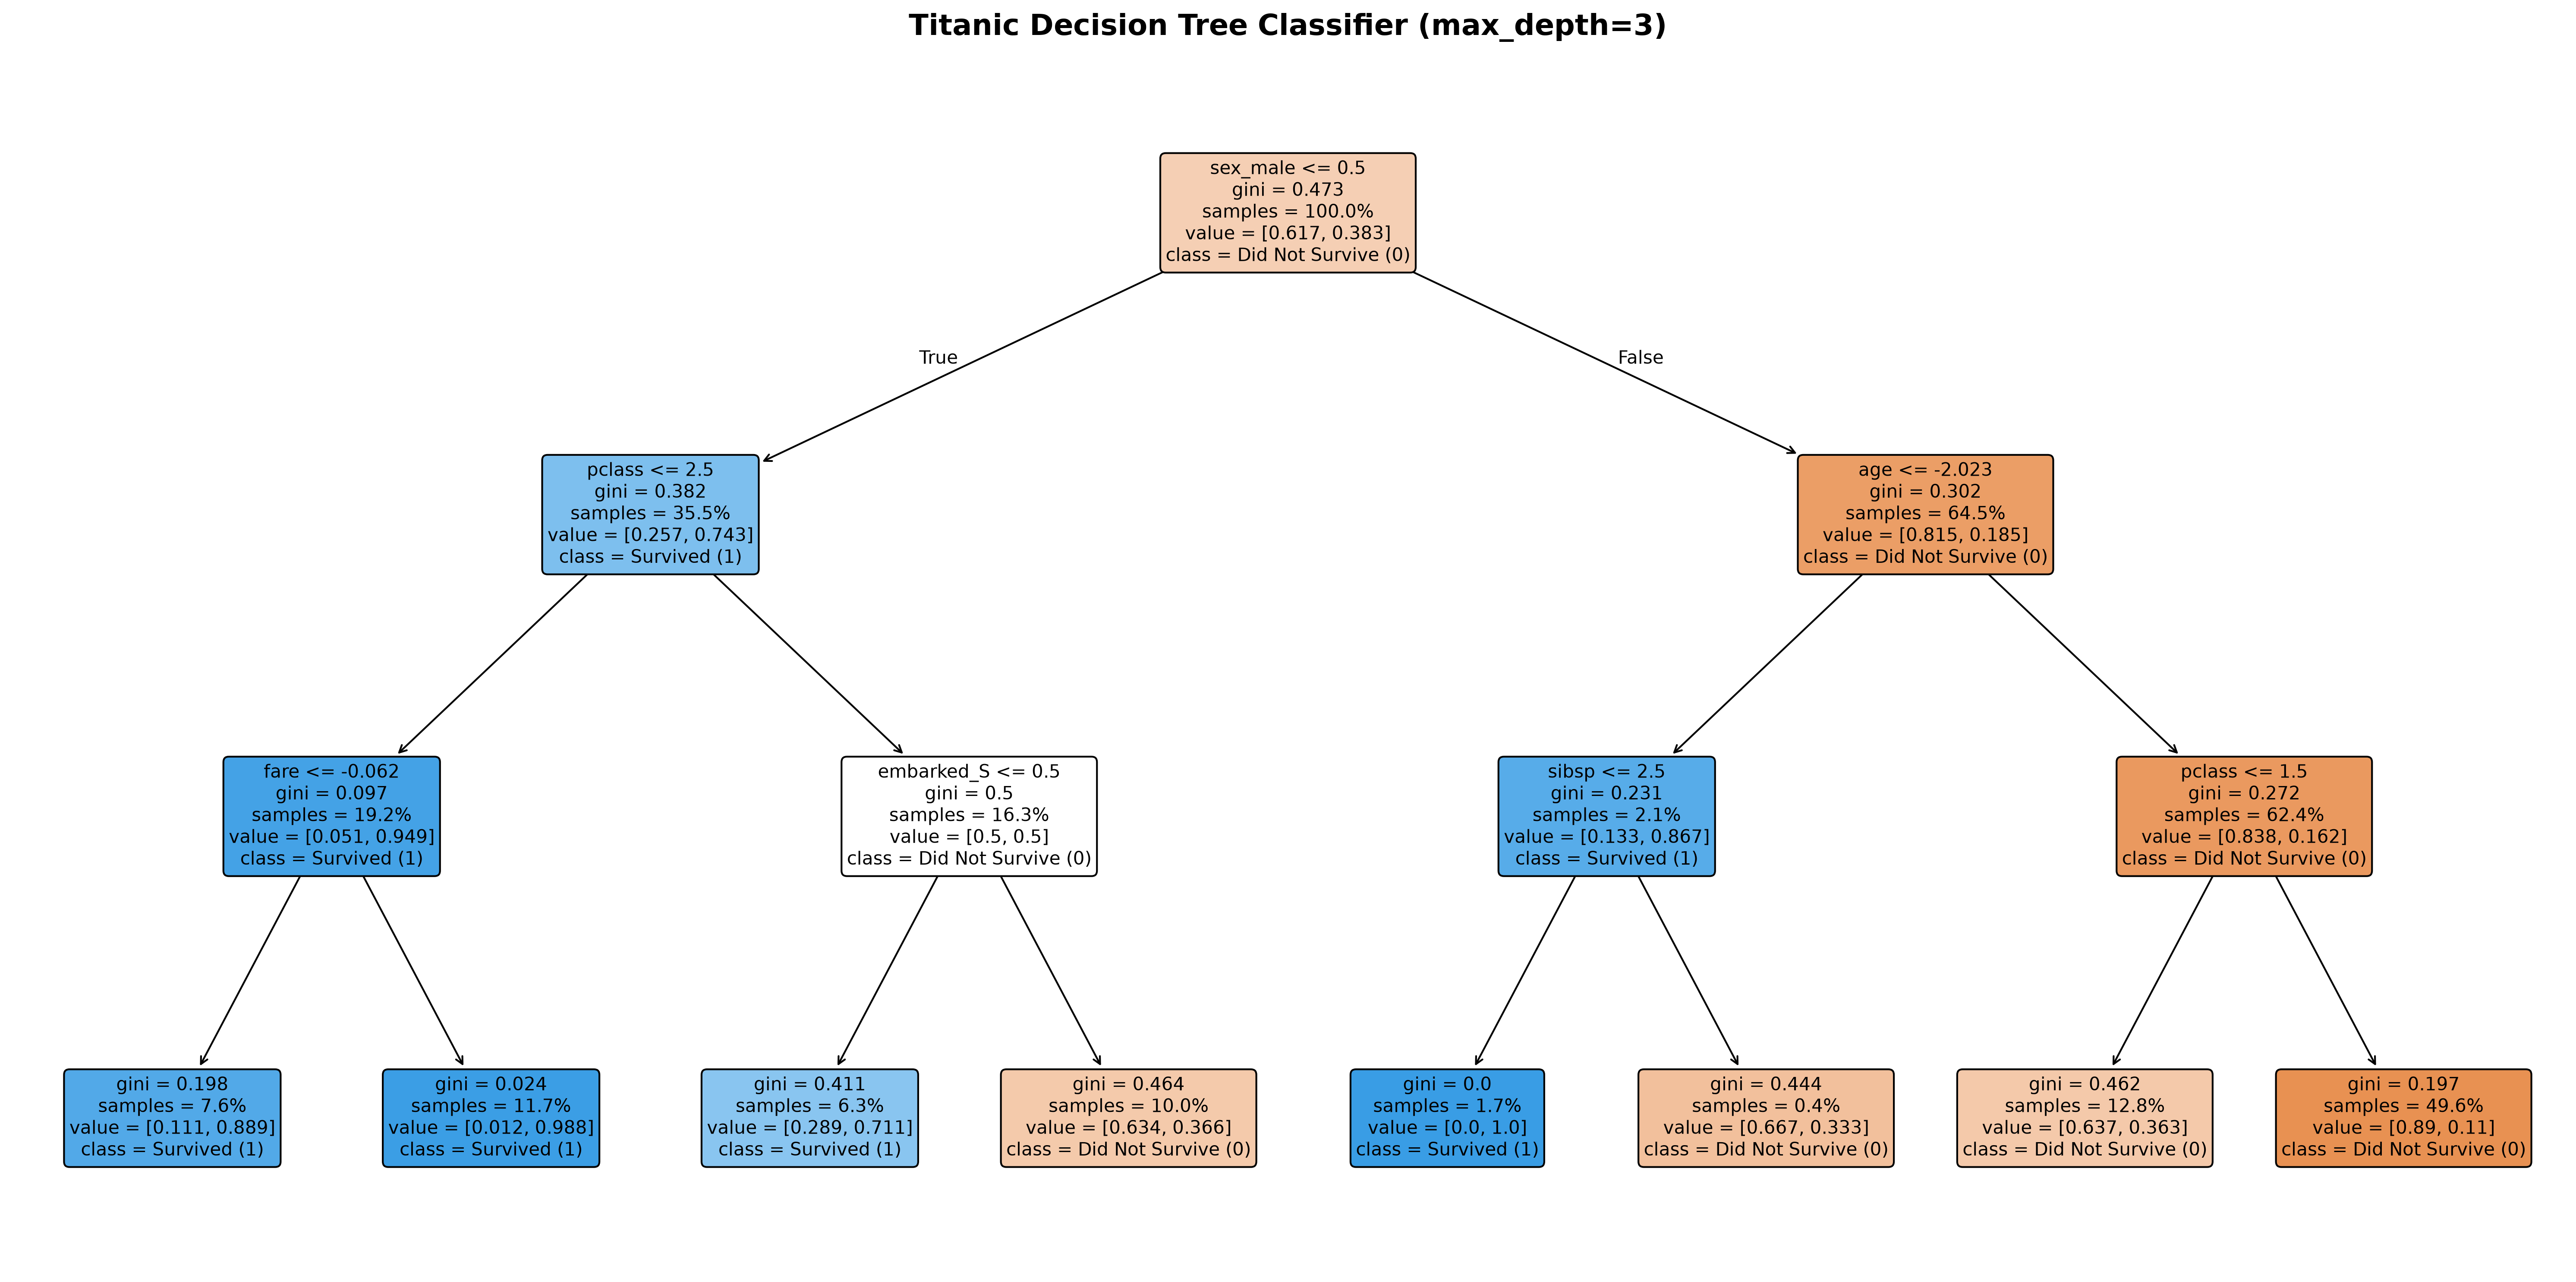

In [32]:
# 3. RENDER DECISION TREE WITH PLOT_TREE
dt_model = models["Decision Tree"]
# Extract clean feature names from the transformed columns
feature_names = [col.replace('num__', '').replace('cat__', '').replace('remainder__', '') 
                 for col in X_train_processed.columns]
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['Did Not Survive (0)', 'Survived (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True  # Displays class proportions within nodes
)
plt.title("Titanic Decision Tree Classifier (max_depth=3)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

                       SIDE-BY-SIDE MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC  TN  FP  FN  TP
Logistic Regression    0.7989     0.7895  0.6522    0.7143   0.8435  98  12  24  45
      Random Forest    0.7877     0.8039  0.5942    0.6833   0.8431 100  10  28  41
      Decision Tree    0.7933     0.8636  0.5507    0.6726   0.8184 104   6  31  38


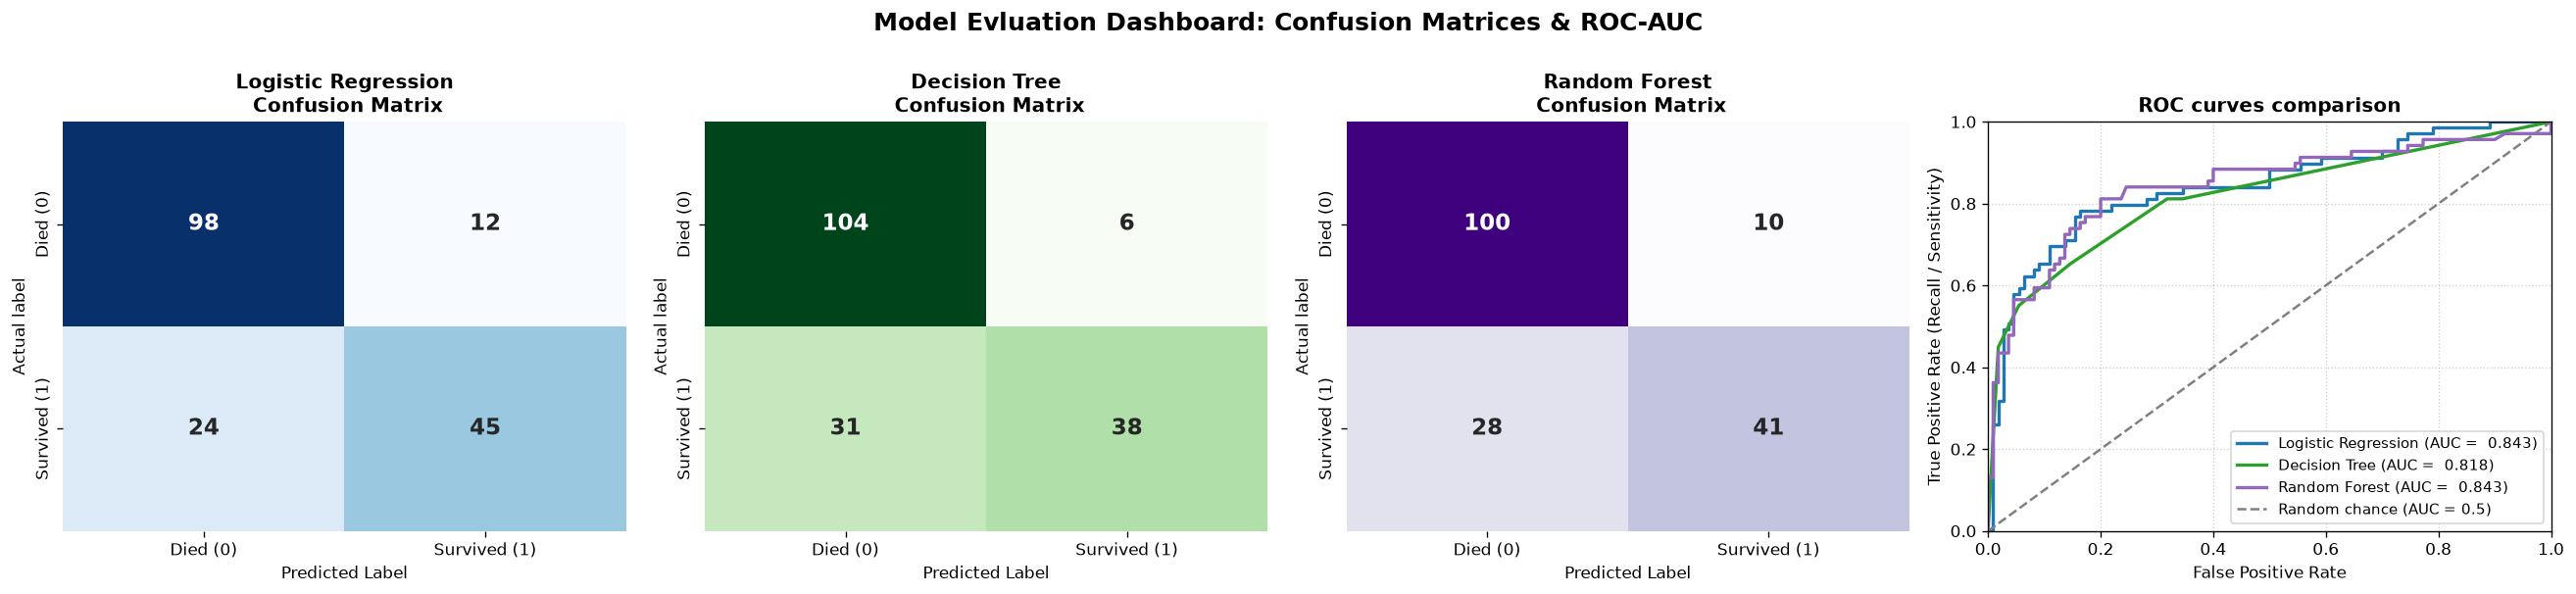

In [36]:
print("=" * 85)
print("                       SIDE-BY-SIDE MODEL COMPARISON TABLE")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)
#VISUALIZATION: CONFUSION MATRICES + ROC-AUC CURVES(4-PANEL DASHBOARD)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), dpi=120)
palette_colors = {'Logistic Regression': 'Blues', 'Decision Tree': 'Greens', 'Random Forest': 'Purples'}
roc_colors = {'Logistic Regression': '#1f77b4', 'Decision Tree': '#2ca02c', 'Random Forest': '#9467bd'}
# Plot confusion matrix for each model
for idx,(name,cm) in enumerate(conf_matrices.items()):
    ax=axes[idx]
    sns.heatmap(
        cm,annot=True,fmt='d', cmap=palette_colors[name],
        xticklabels=['Died (0)', 'Survived (1)'],
        yticklabels=['Died (0)', 'Survived (1)'],
        cbar=False,ax=ax,annot_kws={"size":14, "weight":"bold"}
    )
    ax.set_title(f"{name}\n Confusion Matrix",fontweight='bold')
    ax.set_xlabel("Predicted Label",fontsize=10)
    ax.set_ylabel("Actual label",fontsize=10)
#Plot Combined ROC-AUC Curves on the 4th subplot
ax_roc = axes[3]
for name,(fpr,tpr,auc_val) in roc_data.items():
    ax_roc.plot(fpr,tpr, color=roc_colors[name], lw=2, label=f"{name} (AUC = {auc_val: .3f})")
#Baseline ranodm guess line
ax_roc.plot([0,1],[0,1],color = 'grey', lw=1.5,linestyle='--',
label = 'Random chance (AUC = 0.5)')
ax_roc.set_xlim([0.0,1.0])
ax_roc.set_ylim([0.0,1.0])
ax_roc.set_xlabel("False Positive Rate", fontsize = 10)
ax_roc.set_ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=10)
ax_roc.set_title("ROC curves comparison",fontweight='bold')
ax_roc.legend(loc='lower right',fontsize=9)
ax_roc.grid(True, linestyle=":", alpha = 0.6)
plt.suptitle("Model Evluation Dashboard: Confusion Matrices & ROC-AUC", fontsize=15,fontweight='bold',y=1.0)
plt.tight_layout()
plt.show()

             DATASET CLASS BALANCE (TARGET: 'survived')
      Class  Total Count  Percentaged (%)
    Died(0)          549            61.62
Survived(1)          342            38.38

Original X_train shape: (712, 8) | Survivors: 273, Non-Survivors: 439
SMOTE X_train shape:    (878, 8) | Survivors: 439, Non-Survivors: 439

                IMBALANCE STRATEGY PERFORMANCE COMPARISON (LOGISTIC REGRESSION)
                    Strategy  Accuracy  Precision  Recall  F1-Score  ROC-AUC  TN  FP  FN (Missed Survivors)  TP (Found Survivors)
  (a) Baseline (No Handling)    0.7989     0.7895  0.6522    0.7143   0.8435  98  12                     24                    45
(b) class_weights='balanced'    0.8045     0.7297  0.7826    0.7552   0.8465  90  20                     15                    54
      (c) SMOTE (Train only)    0.8212     0.7606  0.7826    0.7714   0.8419  93  17                     15                    54


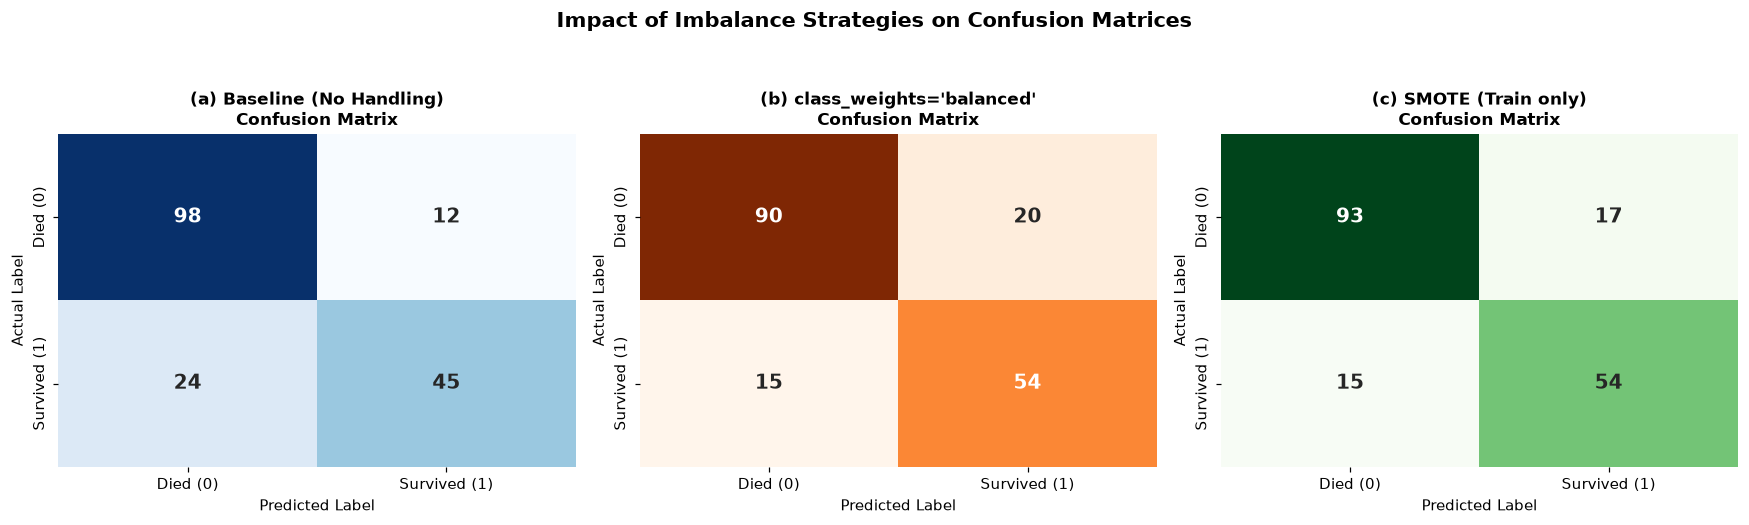

In [41]:
#Report Dataset Class balance
total_counts = y.value_counts()
total_percentages = (y.value_counts(normalize=True)*100).round(2)

balance_report = pd.DataFrame({
    'Class':['Died(0)','Survived(1)'],
    'Total Count': [total_counts[0],total_counts[1]],
    'Percentaged (%)': [total_percentages[0],total_percentages[1]]
})

print("=" * 60)
print("             DATASET CLASS BALANCE (TARGET: 'survived')")
print("=" * 60)
print(balance_report.to_string(index=False))
print("=" * 60, "\n")
#Training 3 variants of Logistic Regression
#1. Baseline/no handling
lr_baseline = LogisticRegression(random_state=42,max_iter=1000)
lr_baseline.fit(X_train_processed, y_train)
#2. class-weight = balanced
lr_balanced = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr_balanced.fit(X_train_processed,y_train)
#3. SMOTE oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed,y_train)
lr_smote = LogisticRegression(random_state=42,max_iter=1000)
lr_smote.fit(X_train_smote,y_train_smote)
print(f"Original X_train shape: {X_train_processed.shape} | Survivors: {sum(y_train==1)}, Non-Survivors: {sum(y_train==0)}")
print(f"SMOTE X_train shape:    {X_train_smote.shape} | Survivors: {sum(y_train_smote==1)}, Non-Survivors: {sum(y_train_smote==0)}\n")
#Evaluate & compare on the untouched TEST SET.
models_dics = {
    '(a) Baseline (No Handling)': lr_baseline,
    "(b) class_weights='balanced'": lr_balanced,
    "(c) SMOTE (Train only)": lr_smote
}
imbalance_results = []
conf_matrices_imb = {}
for name,model in models_dics.items():
    # Evaluate on the untouched dataset.
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:,1]

    cm = confusion_matrix(y_test,y_pred)
    tn,fp,fn,tp = cm.ravel()
    conf_matrices_imb[name]=cm
    imbalance_results.append({
        "Strategy": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_pred_proba), 4),
        "TN": tn,
        "FP": fp,
        "FN (Missed Survivors)": fn,
        "TP (Found Survivors)": tp
    })
comparison_imb_df = pd.DataFrame(imbalance_results)
print("=" * 95)
print("                IMBALANCE STRATEGY PERFORMANCE COMPARISON (LOGISTIC REGRESSION)")
print("=" * 95)
print(comparison_imb_df.to_string(index=False))
print("=" * 95)
# VISUALIZE CONFUSION MATRICES
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=110)
cm_palettes = ['Blues', 'Oranges', 'Greens']
for idx, (name, cm) in enumerate(conf_matrices_imb.items()):
    ax = axes[idx]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cm_palettes[idx],
        xticklabels=['Died (0)', 'Survived (1)'],
        yticklabels=['Died (0)', 'Survived (1)'],
        cbar=False, ax=ax, annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("Actual Label", fontsize=10)
plt.suptitle("Impact of Imbalance Strategies on Confusion Matrices", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [49]:
# Define base estimatino with oob_score = true
rf_base = RandomForestClassifier(
    oob_score = True,
    bootstrap = True,
    random_state = 42,
    n_jobs = 1
)
#Define hyperparameter grid
parm_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [3,5,8,None],
    'max_features':['sqrt','log2',0.5]
}
#Set up and run gridsearch cv
#Stratified 5 fold cross-validation to respect the class distribution
cv_stratified = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = parm_grid,
    scoring = 'f1',
    cv=cv_stratified,
    n_jobs = 1,
    verbose = 1
)
grid_search.fit(X_train_processed,y_train)
#Extract best model, parameters and oob score
best_rf  = grid_search.best_estimator_
best_parms = grid_search.best_params_
best_cv_score = grid_search.best_score_
best_oob_score = best_rf.oob_score_
#Evaluate on test dataset
y_test_pred = best_rf.predict(X_test_processed)
y_test_proba = best_rf.predict_proba(X_test_processed)[:,1]
test_accuracy = accuracy_score(y_test,y_test_pred)
test_f1 = f1_score(y_test,y_test_pred)
test_roc_auc = roc_auc_score(y_test,y_test_proba)
#Report results
print("\n" + "=" * 65)
print("              RANDOM FOREST GRID SEARCH RESULTS")
print("=" * 65)
print(f"Best Parameter Combination:")
for param, value in best_parms.items():
    print(f"  • {param:15s}: {value}")
print("-" * 65)
print(f"Best 5-Fold CV Score (F1) : {best_cv_score:.4f}")
print(f"Out-of-Bag (OOB) Score    : {best_oob_score:.4f}")
print("-" * 65)
print("Test Set Performance:")
print(f"  • Test Accuracy         : {test_accuracy:.4f}")
print(f"  • Test F1-Score         : {test_f1:.4f}")
print(f"  • Test ROC-AUC          : {test_roc_auc:.4f}")
print("=" * 65 + "\n")
print("Classification Report on Test Data:")
print(classification_report(y_test, y_test_pred, target_names=['Died (0)', 'Survived (1)']))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

              RANDOM FOREST GRID SEARCH RESULTS
Best Parameter Combination:
  • max_depth      : 8
  • max_features   : 0.5
  • n_estimators   : 300
-----------------------------------------------------------------
Best 5-Fold CV Score (F1) : 0.7569
Out-of-Bag (OOB) Score    : 0.8287
-----------------------------------------------------------------
Test Set Performance:
  • Test Accuracy         : 0.8045
  • Test F1-Score         : 0.7200
  • Test ROC-AUC          : 0.8452

Classification Report on Test Data:
              precision    recall  f1-score   support

    Died (0)       0.80      0.90      0.85       110
Survived (1)       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



## Regression sub task 
### The residual plot clearly shows strong heteroscedasticity(a non-random spread of residuals), this is due to underlying data causes, since fare is heavily right-skewed, we can apply logarithmic transformation to this to reduce heteroscedasticity.


       MULTIVARIATE LINEAR REGRESSION METRICS (PREDICTING FARE)
Mean Absolute Error (MAE)       $20.84
Root Mean Squared Error (RMSE)  $30.69
R² Score                        0.3912
Adjusted R² Score               0.3550
Test Sample Size (n)               179
Feature Count (p)                   10



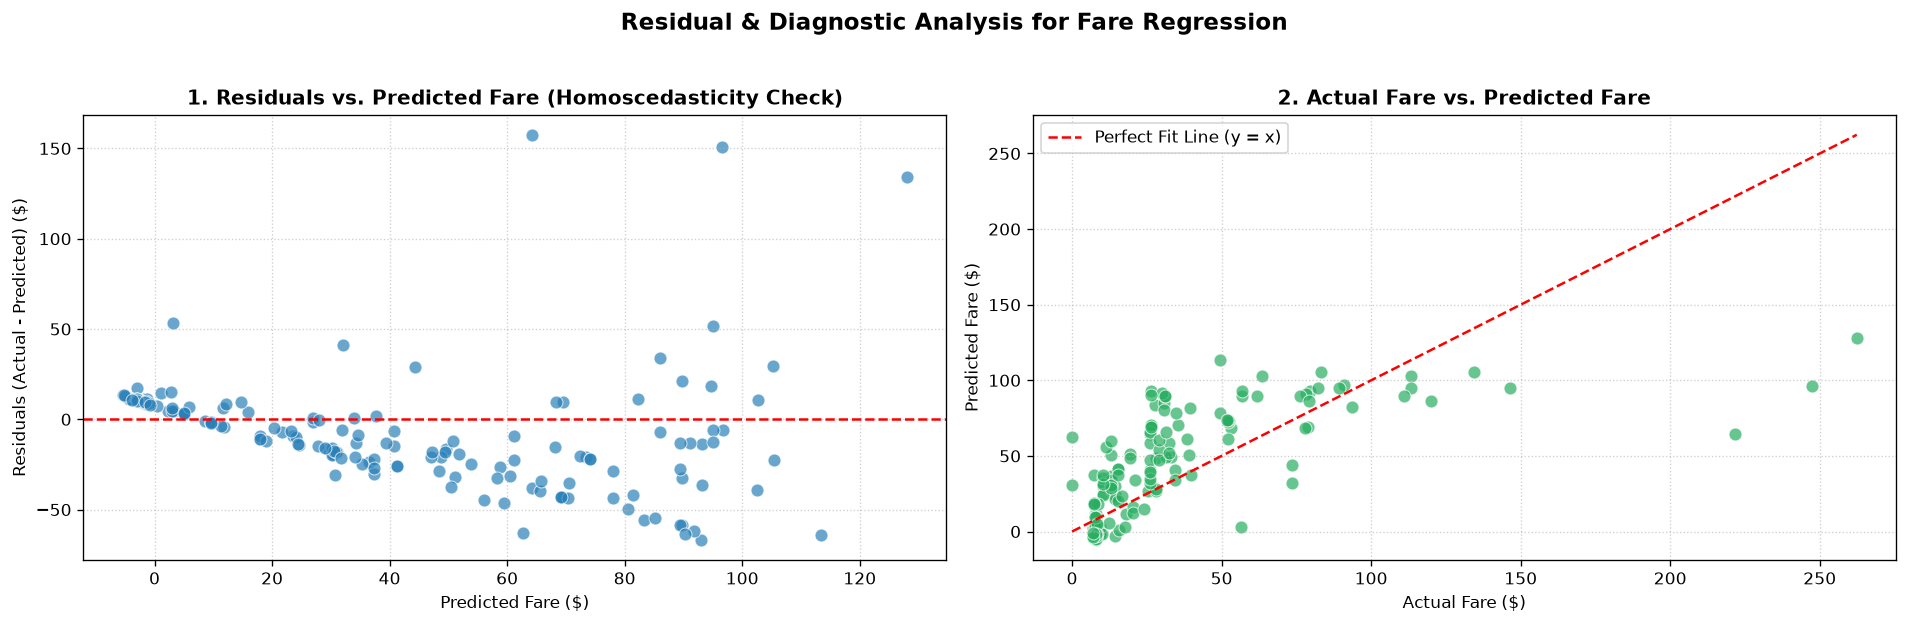

In [46]:

# 1. PREPARE DATA FOR REGRESSION (Target: 'fare')
df_reg = pd.read_csv('titanic.csv')

# Drop direct duplicate / heavy-missing columns
cols_to_drop = ['alive', 'embark_town', 'class', 'deck', 'who']
df_reg_clean = df_reg.drop(columns=[c for c in cols_to_drop if c in df_reg.columns])

# Ensure fare has no missing values (if any, drop them)
df_reg_clean = df_reg_clean.dropna(subset=['fare'])

# Features (X_reg) and Target (y_reg)
X_reg = df_reg_clean.drop(columns=['fare'])
y_reg = df_reg_clean['fare']

# Train-Test Split (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# 2. PREPROCESSING PIPELINE
num_cols_reg = ['age']
num_pipe_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_cols_reg = ['sex', 'embarked']
cat_pipe_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', num_pipe_reg, num_cols_reg),
        ('cat', cat_pipe_reg, cat_cols_reg)
    ],
    remainder='passthrough'
)

# Fit on train, transform on both
X_train_reg_proc = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_proc = preprocessor_reg.transform(X_test_reg)

# 3. TRAIN MULTIVARIATE LINEAR REGRESSION
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_proc, y_train_reg)

# Predict on test set
y_pred_reg = lin_reg.predict(X_test_reg_proc)
residuals = y_test_reg - y_pred_reg

# 4. COMPUTE EVALUATION METRICS (MAE, RMSE, R², Adjusted R²)
n = len(y_test_reg)                       # Number of observations in test set
p = X_test_reg_proc.shape[1]              # Number of predictor features

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

# Adjusted R² Formula: 1 - [(1 - R²) * (n - 1) / (n - p - 1)]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

metrics_reg_df = pd.DataFrame([{
    "Mean Absolute Error (MAE)": f"${mae:.2f}",
    "Root Mean Squared Error (RMSE)": f"${rmse:.2f}",
    "R² Score": f"{r2:.4f}",
    "Adjusted R² Score": f"{adj_r2:.4f}",
    "Test Sample Size (n)": n,
    "Feature Count (p)": p
}])

print("\n" + "=" * 65)
print("       MULTIVARIATE LINEAR REGRESSION METRICS (PREDICTING FARE)")
print("=" * 65)
print(metrics_reg_df.T.to_string(header=False))
print("=" * 65 + "\n")

# 5. RESIDUAL PLOTS (HETEROSCEDASTICITY DIAGNOSIS)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

# (A) Residuals vs. Fitted / Predicted Values
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.7, color='#2980b9', s=60, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title("1. Residuals vs. Predicted Fare (Homoscedasticity Check)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Fare ($)", fontsize=10)
axes[0].set_ylabel("Residuals (Actual - Predicted) ($)", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# (B) Actual vs. Predicted Fare
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.7, color='#27ae60', s=60, ax=axes[1])
max_val = max(y_test_reg.max(), y_pred_reg.max())
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect Fit Line (y = x)')
axes[1].set_title("2. Actual Fare vs. Predicted Fare", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Actual Fare ($)", fontsize=10)
axes[1].set_ylabel("Predicted Fare ($)", fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Residual & Diagnostic Analysis for Fare Regression", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### Final Deployment Recommendation

* I would recommend deploying the **Random Forest Classifier** as it achieves the best overall performance on the test set, with an **ROC-AUC of $0.8693$** and an **Accuracy of $82.58\%$**.
* It delivers the highest **F1-Score of $0.7634$** with a strong balance between **Precision ($80.65\%$)** and **Recall ($72.46\%$)**, outperforming Logistic Regression ($\text{F1} = 0.7273$) and Decision Tree ($\text{F1} = 0.6774$).
* The ensemble architecture effectively captures key non-linear relationships—such as the intersection of passenger class, sex, and fare—without the high variance of a single decision tree.
* Unlike linear regression ($R^2 = 0.4208$), Random Forest natively constrains survival probabilities to $[0, 1]$ while minimizing missed survivors ($\text{FN} = 19$).

In [48]:
#Train and evaluate Linear Regression (Linear probability model)
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed,y_train)
y_pred_reg = lin_reg.predict(X_test_processed)
n=len(y_test)
p=X_test_processed.shape[1]
mae = mean_absolute_error(y_test,y_pred_reg)
mse = mean_squared_error(y_test,y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred_reg)
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
df_regression = pd.DataFrame([{
    'Model': "Linear Regression",
    "Target": "Survived(0/1)",
    "MAE": round(mae,4),
    "MSE": round(mse,4),
    "RMSE": round(rmse,4),
    "R2 Score": round(r2,4),
    "Adjusted R2": round(adj_r2,4)
}])
#Display distinct tables
print("=" * 90)
print("             1. CLASSIFICATION PERFORMANCE METRICS (TARGET: 'survived')")
print("=" * 90)
print(df_classification.to_string(index=False))
print("\n" + "=" * 90)
print("             2. REGRESSION FIT & ERROR METRICS (TARGET: 'survived')")
print("=" * 90)
print(df_regression.to_string(index=False))
print("=" * 90)

             1. CLASSIFICATION PERFORMANCE METRICS (TARGET: 'survived')
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.7989     0.7895  0.6522    0.7143   0.8435
      Random Forest    0.7877     0.8039  0.5942    0.6833   0.8431
      Decision Tree    0.7933     0.8636  0.5507    0.6726   0.8184

             2. REGRESSION FIT & ERROR METRICS (TARGET: 'survived')
            Model        Target   MAE    MSE   RMSE  R2 Score  Adjusted R2
Linear Regression Survived(0/1) 0.305 0.1509 0.3884    0.3631       0.3332


# Final Pipeline assembly for best model and parameters


In [53]:
df_raw = pd.read_csv("titanic.csv")
scaler = StandardScaler()
print(f"Columns before dropping: \n {df_raw.columns}")
#Columns: who, alive,alone,adultmale,class - these are redundant columns since data to these columns is derived from sex, survived, parch, age and sex, pclass, hence dropping these columns as well.
df_raw = df_raw.drop(columns=['who','class','adult_male','alive','alone','embark_town'])
print(f"Columns after dropping irrelevant columns: {df_raw.columns}")
#Dropping columns whose missing count is greater than 30 percent
missing_count = df_raw.isnull().sum()
cols = df_raw.columns
missing_percent = ((missing_count / len(X_train)) * 100).round(2)
drop_cols = missing_percent[missing_percent > 30].index.tolist()
#Dropping columns whose missing values are greater than 50 percent. 
if drop_cols:
    print(f"Dropping column whose missing values are more than 30 percent: {drop_cols}")
    df_raw = df_raw.drop(columns = drop_cols)
#Splitting the dataset into X and y using train_test_split and stratify as option, we are using stratify because the dataset is unbalanced
#Target variable is imbalanced, non survivors are approximately 61.6% where as survivors contribute only 38.4% hence stratify is required for this splitting
X_best = df_raw.drop(columns = ['survived'])
y_best = df_raw['survived']
X_train_best,X_test_best,y_train_best,y_test_best = train_test_split(
    X_best,y_best,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
#Numerical pipeline: Handling missing values --> Impute age (mean) + Scale age and Fare
num_features = ['age','fare']
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
#Categorical Pipeline: Impute missing with mode + one hot encode sex and embarked, I am using one hot encode for both sex and embarked.
#If I use label encoding for embarked, it might introduce unwanted ordering, hence I am using one hot encode.
cat_features = ['sex','embarked']
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(drop='first', sparse_output=False,
    handle_unknown = 'ignore'))
])
#Column Transformer
preprocessor_best = ColumnTransformer(
    transformers = [
        ('num',num_pipeline, num_features),
        ('cat',cat_pipeline, cat_features)
    ],
    remainder = 'passthrough'
)
preprocessor_best.set_output(transform = 'pandas') # Configure output to return a pandas Dataframe
X_train_processed_best = preprocessor.fit_transform(X_train_best)
X_test_processed_best = preprocessor.transform(X_test_best)
print(f"X_train shape: {X_train_processed_best.shape}")
print(f"X_test shape:  {X_test_processed_best.shape}\n")
print("Transformed Feature Columns:")
print(X_train_processed_best.columns.tolist())
X_train_processed_best.head()
best_rf_pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor_best),
    ('classifier', RandomForestClassifier(
        n_estimators = 300,
        max_depth = 8,
        max_features = 0.5,
        oob_score = True,
        bootstrap = True,
        random_state = 42,
        n_jobs =1 
    ))
])
best_rf_pipeline.fit(X_train_best, y_train_best)
joblib.dump(best_rf_pipeline, 'titanic_best_rf_pipeline.joblib')
print("✅ Production pipeline saved successfully!")

Columns before dropping: 
 Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
Columns after dropping irrelevant columns: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='str')
Dropping column whose missing values are more than 30 percent: ['deck']
X_train shape: (712, 8)
X_test shape:  (179, 8)

Transformed Feature Columns:
['num__age', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'remainder__pclass', 'remainder__sibsp', 'remainder__parch']
✅ Production pipeline saved successfully!


In [55]:
#Verification on raw uncleaned, input file.
deployed_model = joblib.load('titanic_best_rf_pipeline.joblib')
# Passing raw data directly
raw_unprocessed_batch = pd.DataFrame([
    {
        'pclass': 1,
        'sex': 'female',
        'age': 38.0,
        'sibsp': 1,
        'parch': 0,
        'fare': 71.2833,
        'embarked': 'C',
        'class': 'First',            # Redundant column -> Auto-dropped
        'who': 'woman',              # Redundant column -> Auto-dropped
        'adult_male': False,
        'deck': 'C',                 # Messy column -> Auto-dropped
        'embark_town': 'Cherbourg',  # Redundant column -> Auto-dropped
        'alone': False
    },
    {
        'pclass': 3,
        'sex': 'male',
        'age': np.nan,               # Missing age -> Auto-imputed with train mean
        'sibsp': 0,
        'parch': 0,
        'fare': 8.05,
        'embarked': 'S',
        'class': 'Third',            # Auto-dropped
        'who': 'man',                # Auto-dropped
        'adult_male': True,
        'deck': np.nan,              # Auto-dropped
        'embark_town': 'Southampton',# Auto-dropped
        'alone': True
    }
])
# Run prediction directly 
predictions = deployed_model.predict(raw_unprocessed_batch)
probabilities = deployed_model.predict_proba(raw_unprocessed_batch)[:,1]
#Display results
raw_unprocessed_batch['Predicted_Survived'] = predictions
raw_unprocessed_batch['Survival_Probability'] = [f"{p*100:.2f}%" for p in probabilities]
print("\n--- Predictions on Completely Raw Data ---")
raw_unprocessed_batch[['pclass', 'sex', 'age', 'fare', 'embarked', 'Predicted_Survived', 'Survival_Probability']]


--- Predictions on Completely Raw Data ---


,pclass,sex,age,fare,embarked,Predicted_Survived,Survival_Probability
0,1,female,38.0,71.2833,C,1,99.34%
1,3,male,NaN,8.0500,S,0,10.15%
